# MMC Chatbot — Advanced Analysis (Responses, message-level)

Topic tinting, emergent-theme detection, needs mapping and cross-cuts over the
**individual messages** migrants send the bot. The `Messages` field packs every
user turn separated by line breaks, so we explode it into **one row per message**
(~3k messages inside 946 users) and analyse each message on its own while keeping
it linked to the user's full interaction. Every section opens with **What this
shows / Why it matters**; non-obvious choices get a **Technical note**.

> **Technical note — message-level, GPU, no cache.** Each message is embedded and
> classified fresh on the local GPU (NVIDIA, CUDA) — the whole NLP pass runs in a
> couple of minutes, so nothing is cached to disk. Falls back to CPU if no GPU is
> present. Self-reported user text only: there is no bot-output log, which bounds
> what we can measure (see the final *Data gaps* section).

In [1]:
import sys, warnings, time
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from palette import *          # brand colors, BLUES, bar_colors(), rcParams
import mmc_data, mmc_entities, mmc_text

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
GPU = 0 if DEVICE == 'cuda' else -1

df   = mmc_data.load_responses()          # one row per user
meal = mmc_data.load_meal()               # MEAL survey (satisfaction)
msgs = mmc_data.load_messages(df)         # one row per user message (the spine)

print(f"users: {len(df)}  |  messages: {len(msgs)}  |  device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == 'cuda' else ""))

users: 946  |  messages: 2993  |  device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


In [2]:
# The 7 official MMC categories, each with a short Spanish hypothesis. The
# category KEYS (English) are what gets displayed on every chart; the VALUES
# stay in Spanish because they are the hypotheses fed to the Spanish zero-shot
# classifier. Short labels were chosen by measuring agreement against the bot's
# own Chat_summary labels (see the validation cell in Section 3): they gave the
# best balanced accuracy — long keyword-stuffed descriptions collapsed the
# classifier onto one or two categories. Edit the wording to steer the classifier.
MMC_LABELS = {
    "legal documentation":     "documentación legal y trámites migratorios",
    "humanitarian assistance": "ayuda humanitaria",
    "employment":              "empleo",
    "services":                "salud y servicios",
    "protection":              "protección y seguridad",
    "journey information":     "información de viaje",
    "organization search":     "búsqueda de una organización",
}
MMC_CATS = list(MMC_LABELS)
COURTESY = "courtesy / non-substantive"
NOISE    = "unclustered"
FRAG     = "short fragment"                 # location/greeting fragments, not a theme
NON_TOPIC_CATS = [COURTESY, NOISE, FRAG]    # excluded from topic cross-cuts

# one distinct colour per category (brand colours first, then muted extras)
CAT_COLORS = {
    "legal documentation":     AGUA,
    "humanitarian assistance": ARBOL,
    "employment":              AMEBA,
    "services":                MADERA,
    "protection":              "#c9788f",
    "journey information":     "#4a9d9c",
    "organization search":     "#d9a45b",
    "emergent":                "#8e5572",
    COURTESY:                  HONGO,
    NOISE:                     "#cfcfcf",
    FRAG:                      "#b0b0b0",
}
def cat_palette(cats):
    return [CAT_COLORS.get(c, NEGRO) for c in cats]

## 1. Loading & cleaning

**What this shows.** How many users and messages we have, how complete each field
is, and how many messages people send. **Why it matters.** Every later number
rests on the message explosion being correct and on knowing how much text each
person actually wrote.

,non_null,pct
Nationality,919,97.1
city_canon,946,100.0
age_num,946,100.0
Gender,946,100.0
Minors,946,100.0
Messages,835,88.3
Chat_summary,844,89.2
ts,946,100.0


date range: 2026-03-25 13:43:06.306000 → 2026-07-03 06:16:46.166000
unique phones: 917
messages/user — median 3, mean 3.6, max 42  |  single-message users: 24.8%


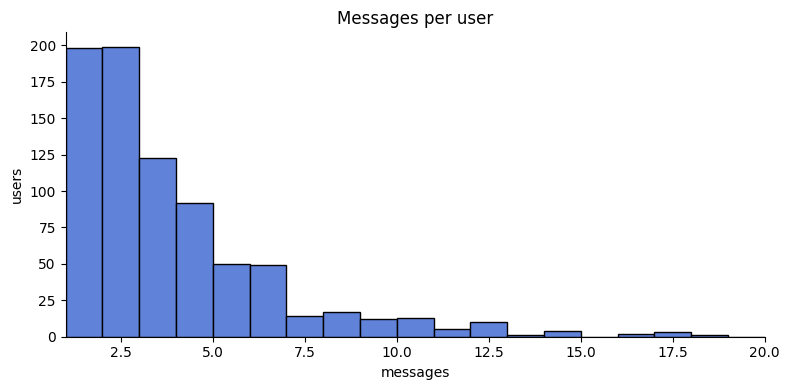

In [3]:
comp = pd.DataFrame({
    "non_null": df.notna().sum(),
    "pct": (df.notna().mean() * 100).round(1),
})
display(comp.loc[["Nationality","city_canon","age_num","Gender","Minors",
                  "Messages","Chat_summary","ts"]])
print("date range:", df["ts"].min(), "→", df["ts"].max())
print("unique phones:", df["phone"].nunique())

# messages per user (from the exploded spine)
per_user = msgs.groupby("phone")["n_msgs_user"].first()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_user, bins=range(1, int(per_user.max()) + 2), color=AGUA, edgecolor=NEGRO)
ax.set_title("Messages per user")
ax.set_xlabel("messages"); ax.set_ylabel("users"); ax.set_xlim(1, 20)
plt.tight_layout()
print(f"messages/user — median {per_user.median():.0f}, mean {per_user.mean():.1f}, "
      f"max {per_user.max()}  |  single-message users: {(per_user==1).mean()*100:.1f}%")

## 2. Embedding & clustering

**What this shows.** Every message placed in a semantic space and grouped into
data-driven clusters — no manual labelling. **Why it matters.** Clusters reveal
the natural sub-themes people write about and give Section 3 the structure it
needs to separate covered topics from emergent ones.

> **Technical note.** We embed the raw Spanish `message` with
> `intfloat/multilingual-e5-large` (the required `"query: "` prefix, GPU fp16),
> reduce with UMAP (`random_state=42`, reproducible) and cluster with HDBSCAN.
> Label `-1` is the noise bucket. Keywords per cluster come from a Spanish
> c-TF-IDF (stop-words + courtesy words removed).

In [4]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan

texts = msgs["message"].tolist()

t = time.time()
_embedder = SentenceTransformer("intfloat/multilingual-e5-large", device=DEVICE)
if DEVICE == "cuda":
    _embedder = _embedder.half()
emb = _embedder.encode(["query: " + t_ for t_ in texts], batch_size=32,
                       normalize_embeddings=True, show_progress_bar=False)
emb = np.asarray(emb, dtype="float32")
del _embedder
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print(f"embedded {len(texts)} messages in {time.time()-t:.1f}s  shape={emb.shape}")

red5 = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
            metric="cosine", random_state=42).fit_transform(emb)
msgs["cluster"] = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5).fit_predict(red5)

n_clusters = msgs["cluster"].nunique() - (1 if (msgs["cluster"] == -1).any() else 0)
print(f"{n_clusters} clusters  |  noise {(msgs['cluster']==-1).sum()} "
      f"({(msgs['cluster']==-1).mean()*100:.1f}%)")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embedded 2993 messages in 16.5s  shape=(2993, 1024)
59 clusters  |  noise 712 (23.8%)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

def cluster_keywords(frame, topn=6):
    "Top Spanish c-TF-IDF terms per cluster (one pseudo-doc per cluster)."
    grp = frame[frame["cluster"] >= 0].groupby("cluster")["message"].apply(" ".join)
    vec = TfidfVectorizer(stop_words=mmc_text.SPANISH_STOPWORDS,
                          ngram_range=(1, 2), min_df=1)
    X = vec.fit_transform(grp.values)
    terms = np.array(vec.get_feature_names_out())
    out = {}
    for i, cl in enumerate(grp.index):
        row = X[i].toarray().ravel()
        out[cl] = ", ".join(terms[row.argsort()[::-1][:topn]])
    return out

KW = cluster_keywords(msgs)
print(f"keywords computed for {len(KW)} clusters")

keywords computed for 59 clusters


## 3. Mixed coding — MMC tinting + emergent themes

**What this shows.** Every message "tinted" with one of MMC's 7 categories, with
the messages that don't fit cleanly surfaced as **emergent / cross-cutting**
themes. **Why it matters.** It keeps results comparable to MMC's own framework
while revealing demand the taxonomy misses — the core deliverable.

> **Technical note — tinting is per cluster, using the bot's own labels.** We
> tested a per-message **zero-shot NLI** classifier
> (`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`) but measured it agreeing with the
> bot's `Chat_summary` only ~40% of the time on clean single-message cases — too
> unstable to be the primary label. So the **primary** category is assigned per
> **cluster** by the consensus of the bot's `Chat_summary` labels inside it
> (averaging denoises the individual labels); each message inherits its cluster's
> category. Zero-shot is kept as a secondary cross-check column. A cluster with no
> clear majority (top label < 40%) is **emergent / cross-cutting** — the
> single-label taxonomy can't cleanly place it. Greeting/thanks turns are
> *courtesy*; HDBSCAN noise is *unclustered*; and clusters of very short turns
> (mean < 6 words — bare city names like "Estoy en Cúcuta") are *short fragments*,
> kept out of the emergent set so it holds only real themes.

In [6]:
# Secondary signal — per-message zero-shot NLI, kept only as a cross-check
# (on this data single-message zero-shot is noisy; see the validation cell).
from transformers import pipeline
_clf = pipeline("zero-shot-classification",
                model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=GPU)
cand = list(MMC_LABELS.values()); inv = {v: k for k, v in MMC_LABELS.items()}
t = time.time()
res = _clf(texts, cand, multi_label=False,
           hypothesis_template="Este mensaje trata sobre {}.", batch_size=16)
res = res if isinstance(res, list) else [res]
msgs["zshot"] = [inv[r["labels"][0]] for r in res]
del _clf
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print(f"zero-shot cross-check computed in {time.time()-t:.1f}s")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

zero-shot cross-check computed in 44.0s


mmc_category
legal documentation        1193
humanitarian assistance     516
emergent                    178
employment                  131
Name: count, dtype: int64


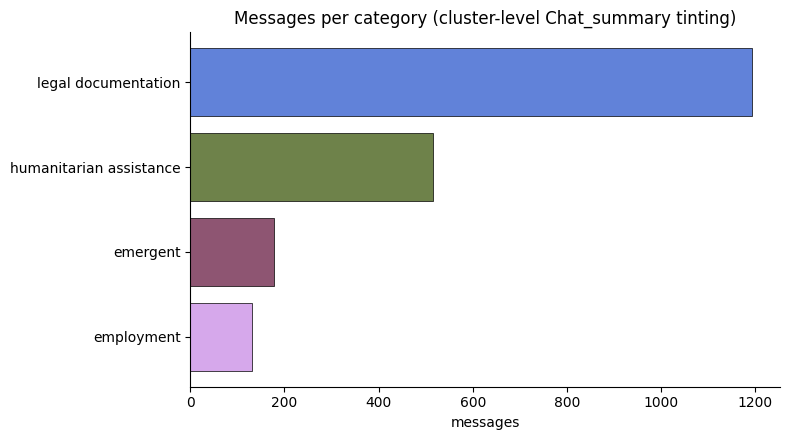

In [7]:
# PRIMARY tinting — label each CLUSTER by the consensus of the bot's own
# Chat_summary labels inside it; every message inherits its cluster's category.
# Averaging over a coherent cluster denoises the individual bot labels. A cluster
# with no clear majority (top label < 40%) is 'emergent'; HDBSCAN noise is
# 'unclustered'.
import re
_CANON = {"legaldocumentation": "legal documentation",
          "humanitarianassistance": "humanitarian assistance",
          "journeyinformation": "journey information",
          "organizationsearch": "organization search"}
def _norm_cs(v):
    if not isinstance(v, str): return None
    s = re.sub(r"\s+", " ", v.lower().lstrip("#").strip().replace("_", " "))
    if "," in s or "hashtag" in s or "use exactly" in s: return None
    return s if s in MMC_CATS else _CANON.get(s.replace(" ", ""))
cs_map = (df.assign(cs=df["Chat_summary"].map(_norm_cs)).dropna(subset=["cs"])
            .drop_duplicates("phone").set_index("phone")["cs"])
msgs["cs"] = msgs["phone"].map(cs_map)          # bot label carried to each message

DOM_TH = 0.40
FRAG_WORDS = 6   # low-consensus clusters shorter than this are location/greeting fragments, not themes
rows, cat_of = [], {}
for cl, g in msgs[msgs["cluster"] >= 0].groupby("cluster"):
    vc = g["cs"].dropna().value_counts(normalize=True)
    dom   = vc.index[0] if len(vc) else None
    share = float(vc.iloc[0]) if len(vc) else 0.0
    zmaj  = g["zshot"].value_counts().index[0]
    words = g["message"].str.split().str.len().mean()
    if share >= DOM_TH:                           # clear bot-label consensus: covered
        cat, emergent = dom, False
    elif words < FRAG_WORDS:                       # low consensus + short = location/greeting fragment
        cat, emergent = FRAG, False
    else:                                          # low consensus + real content = emergent
        cat, emergent = "emergent", True
    cat_of[cl] = cat
    rows.append((cl, len(g), dom, round(share, 2), zmaj, round(words, 1), emergent, KW.get(cl, "")))
tab = pd.DataFrame(rows, columns=["cluster", "n", "dom_cs", "cs_share", "zshot_maj",
                                  "mean_words", "emergent", "keywords"]).set_index("cluster")

msgs["mmc_category"] = msgs["cluster"].map(cat_of)
msgs.loc[msgs["cluster"] == -1, "mmc_category"] = NOISE
msgs.loc[msgs["message"].map(mmc_text.is_courtesy), "mmc_category"] = COURTESY
msgs["is_emergent"] = (msgs["mmc_category"] == "emergent")

dist = msgs.loc[~msgs["mmc_category"].isin(NON_TOPIC_CATS), "mmc_category"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4.5))
order = dist.iloc[::-1]
ax.barh(order.index, order.values, color=cat_palette(order.index), edgecolor=NEGRO, lw=.5)
ax.set_title("Messages per category (cluster-level Chat_summary tinting)")
ax.set_xlabel("messages"); plt.tight_layout()
print(dist)

In [8]:
# Validation — how reliable is the SECONDARY per-message zero-shot? Compare it to
# the bot's Chat_summary on single-message users with one clean label (an honest
# read on a weak, noisy gold). This is why zero-shot is only a cross-check and the
# primary tinting uses cluster consensus instead.
solo = msgs[(msgs["n_msgs_user"] == 1) & msgs["cs"].notna()
            & ~msgs["message"].map(mmc_text.is_courtesy)]
acc = (solo["zshot"] == solo["cs"]).mean()
macro = np.mean([ (solo.loc[solo["cs"] == c, "zshot"] == c).mean()
                  for c in solo["cs"].unique() ])
print(f"zero-shot vs bot Chat_summary on {len(solo)} single-message users: "
      f"accuracy {acc:.2f}, macro-recall {macro:.2f}")

zero-shot vs bot Chat_summary on 207 single-message users: accuracy 0.41, macro-recall 0.41


In [9]:
n_emg = int(tab["emergent"].sum())
print(f"{n_emg} of {len(tab)} clusters are emergent / cross-cutting "
      f"({msgs['is_emergent'].mean()*100:.1f}% of messages) — no clear Chat_summary consensus")
display(tab.sort_values(["emergent", "n"], ascending=False)
        [["n", "dom_cs", "cs_share", "zshot_maj", "mean_words", "emergent", "keywords"]].head(20))

2 of 59 clusters are emergent / cross-cutting (5.9% of messages) — no clear Chat_summary consensus


,n,dom_cs,cs_share,zshot_maj,mean_words,emergent,keywords
cluster,,,,,,,
53,121,legal documentation,0.40,services,17.0,True,"salud, eps, sisben, necesito, puedo, estoy"
32,57,legal documentation,0.39,protection,6.5,True,"medellín, medellin, antioquia, estoy, encuentr..."
39,166,legal documentation,0.87,protection,10.8,False,"ppt, sacar ppt, puedo, sacar, rumv, obtener ppt"
51,114,legal documentation,0.72,protection,7.1,False,"requisitos, trámite, puedo, si, saber, necesito"
11,97,legal documentation,0.90,humanitarian assistance,14.2,False,"salvoconducto, conducto, salvo conducto, salvo..."
52,85,humanitarian assistance,0.64,humanitarian assistance,20.5,False,"soltera, ayuda, madre, niños, madre soltera, años"
35,82,humanitarian assistance,0.57,humanitarian assistance,9.8,False,"ayuda, saber, puedo, quisiera, económica, ayudas"
12,66,employment,0.65,employment,11.6,False,"emprendimiento, ayuda, ayuda emprendimiento, e..."
16,65,employment,0.72,employment,6.5,False,"empleo, conseguir empleo, trabajo, conseguir, ..."


In [10]:
# The emergent themes, with a few real example messages each.
for cl in tab[tab["emergent"]].sort_values("n", ascending=False).index:
    ex = msgs[msgs["cluster"] == cl]
    print(f"\n— cluster {cl}  (n={len(ex)}, mixes {ex['cs'].dropna().nunique()} bot categories)")
    print("  keywords:", KW.get(cl, ""))
    for m in ex["message"].head(3):
        print("   •", m[:100].replace("\n", " "))


— cluster 53  (n=121, mixes 5 bot categories)
  keywords: salud, eps, sisben, necesito, puedo, estoy
   • mi hijo tiene probelmas de salud y no he podido acceder al servicio
   • pero como hago para que mi hijo tenga atención en salud además de urgencias médicas
   • Si ya tengo lo del Sisben me inscribi ya me hicieron la primera visita  dijeron que volvian pero no 

— cluster 32  (n=57, mixes 6 bot categories)
  keywords: medellín, medellin, antioquia, estoy, encuentro, estoy medellín
   • Estoy en Medellín Belén
   • Si en medellín
   • Si necesito qyuda estoy en medelin


### 3.1 Cluster map

**What this shows.** All messages drawn as points; nearby points are semantically
similar. Covered themes are muted grey, **emergent clusters are highlighted**.
**Why it matters.** A visual sanity check — emergent themes should sit as their
own separable blobs, not scattered noise.

> **Technical note.** A second UMAP to 2-D for display only (`random_state=42`);
> the clustering used 5-D. Read *grouping*, not exact coordinates.

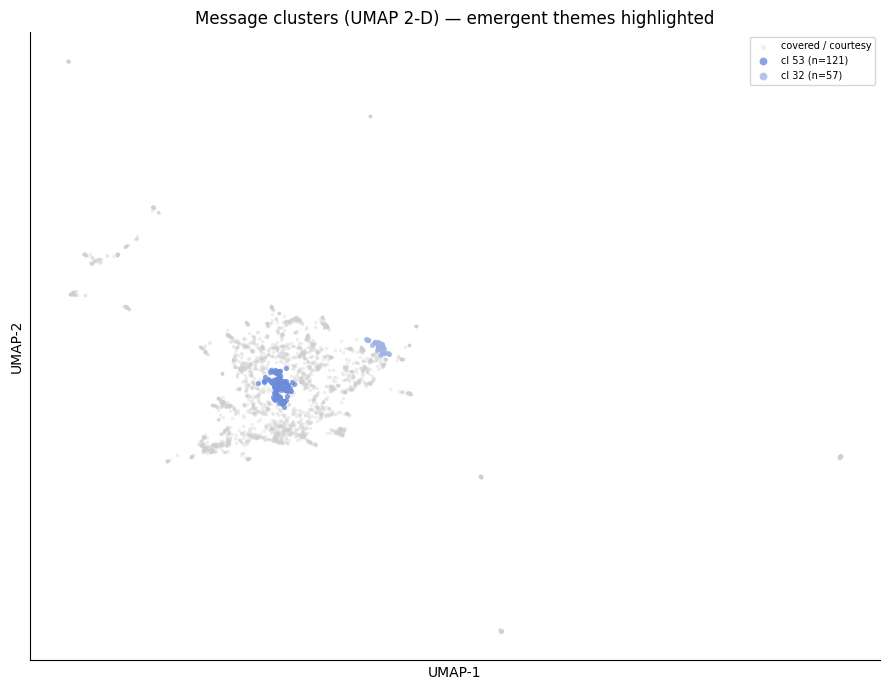

In [11]:
red2 = UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
            metric="cosine", random_state=42).fit_transform(emb)
proj = pd.DataFrame(red2, columns=["x", "y"])
proj["emergent"] = msgs["is_emergent"].values
proj["cluster"]  = msgs["cluster"].values

fig, ax = plt.subplots(figsize=(9, 7))
cov = ~proj["emergent"]
ax.scatter(proj.loc[cov, "x"], proj.loc[cov, "y"], s=6, alpha=.35,
           color="#cfcfcf", linewidths=0, label="covered / courtesy")
emg_clusters = tab[tab["emergent"]].sort_values("n", ascending=False).index
emg_cols = bar_colors(len(emg_clusters))
for col, cl in zip(emg_cols, emg_clusters):
    m = proj["cluster"] == cl
    ax.scatter(proj.loc[m, "x"], proj.loc[m, "y"], s=14, alpha=.8,
               color=col, linewidths=0, label=f"cl {cl} (n={m.sum()})")
ax.set_title("Message clusters (UMAP 2-D) — emergent themes highlighted")
ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=1.5, fontsize=7, loc="best", frameon=True)
plt.tight_layout()

## 4. Most-requested needs (procedures & institutions)

**What this shows.** Which documents, procedures and institutions people mention
most (PPT, EPS, Migración Colombia, …). **Why it matters.** It maps real demand
so MMC can prioritise content and referrals.

> **Technical note.** A curated dictionary (`mmc_entities.ENTITY_PATTERNS`)
> matches accent- and case-insensitively on each Spanish message.

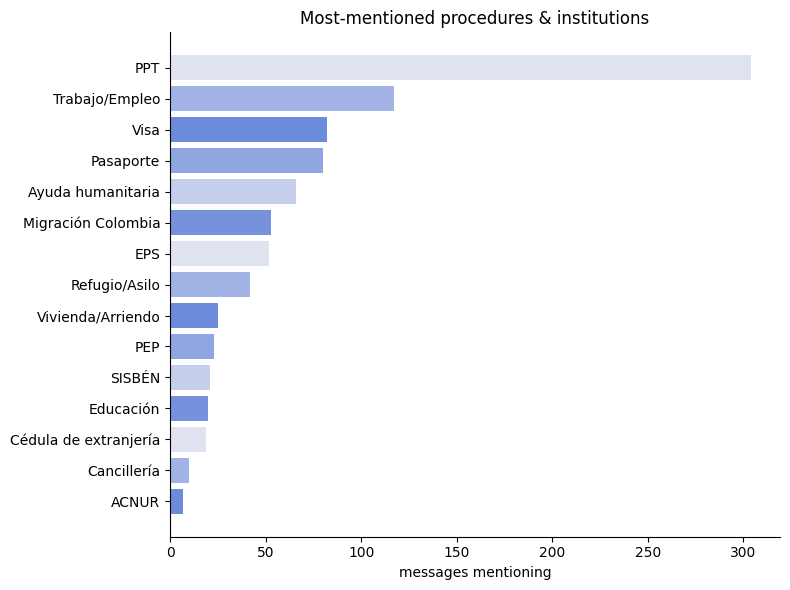

In [12]:
counts = mmc_entities.entity_counts(msgs["message"])
fig, ax = plt.subplots(figsize=(8, 6))
top = counts.head(15).iloc[::-1]
ax.barh(top.index, top.values, color=bar_colors(len(top)))
ax.set_title("Most-mentioned procedures & institutions")
ax.set_xlabel("messages mentioning"); plt.tight_layout()

# per-entity boolean columns for cross-tabs
for ent in counts.index:
    msgs["ent_" + ent] = msgs["message"].fillna("").map(
        lambda t, e=ent: e in mmc_entities.extract_entities(t))

## 5. Geographic analysis by city

**What this shows.** Message volume and category mix across the highest-volume
cities. **Why it matters.** MMC operates in priority cities; this compares where
demand concentrates and how needs differ by place.

> **Technical note.** Cities use the normalised `city_canon` (variants like
> `Bogota`/`Bogotá` merged; non-cities → `Otra`).

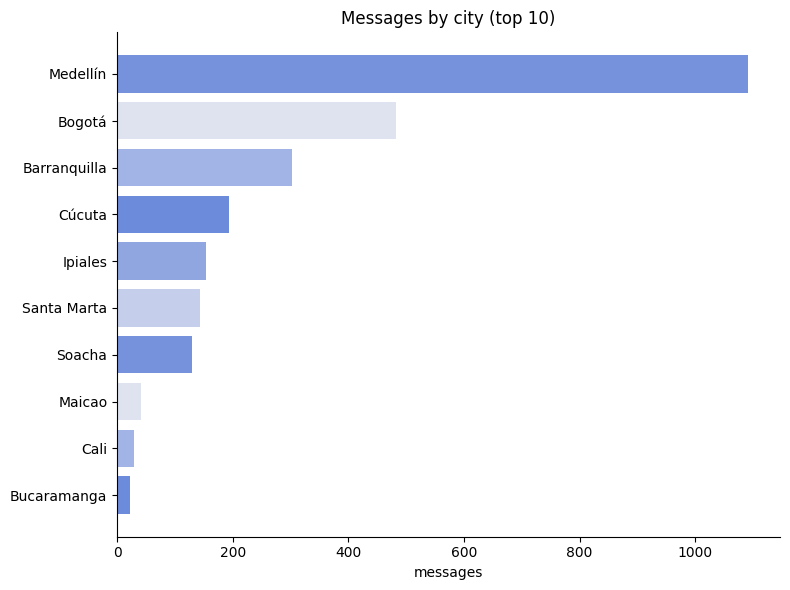

In [13]:
top_cities = msgs.loc[msgs["city_canon"] != "Otra", "city_canon"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 6))
order = top_cities.iloc[::-1]
ax.barh(order.index, order.values, color=bar_colors(len(order)))
ax.set_title("Messages by city (top 10)")
ax.set_xlabel("messages"); plt.tight_layout()

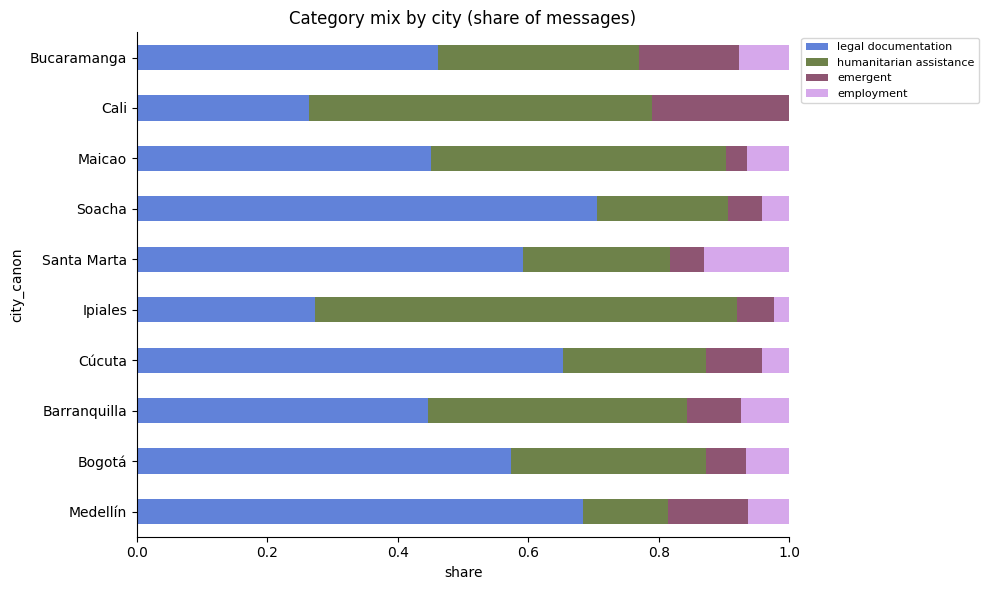

In [14]:
cats = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
        .value_counts().head(6).index)
sub = msgs[msgs["city_canon"].isin(top_cities.index) & msgs["mmc_category"].isin(cats)]
mix = (pd.crosstab(sub["city_canon"], sub["mmc_category"], normalize="index")
       .reindex(index=top_cities.index, columns=cats, fill_value=0))
mix.plot(kind="barh", stacked=True, figsize=(10, 6), color=cat_palette(mix.columns))
plt.title("Category mix by city (share of messages)")
plt.xlabel("share"); plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 6. Temporal analysis — categories over time

**What this shows.** How overall volume and specific categories rise and fall by
date. **Why it matters.** Spikes often track migration-policy events; aligning
them helps MMC anticipate demand.

> **Technical note — one timestamp per user.** The export has a single
> first-contact `Timestamp` per user, so every message of a user shares that
> date; this is session-level timing, not per-message. `EVENTS` is a manual
> overlay — extend it with confirmed policy dates.

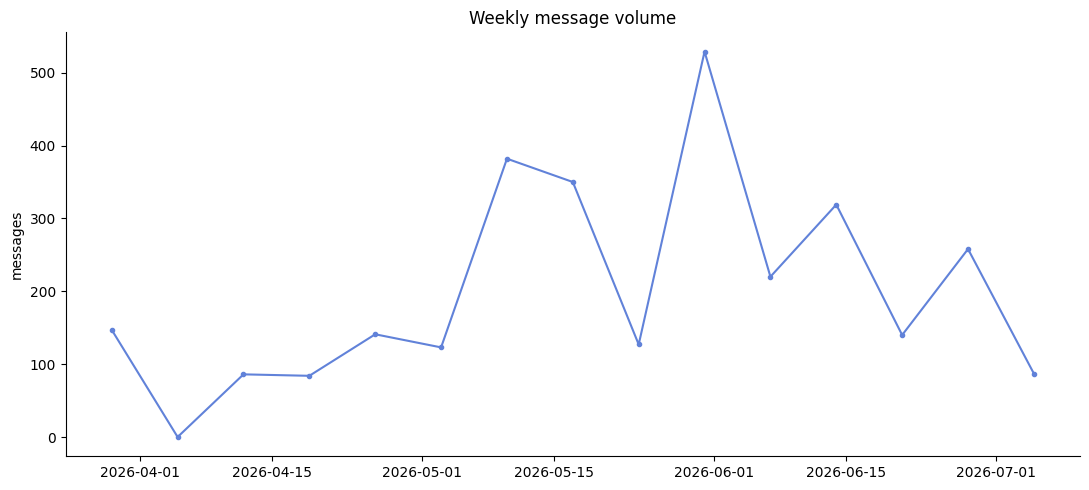

In [15]:
EVENTS = {
    # "2026-04-15": "example policy milestone",
}
weekly = msgs.dropna(subset=["ts"]).set_index("ts").resample("W").size()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly.index, weekly.values, color=AGUA, marker="o", ms=3)
for date, label in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color=MADERA, ls="--", lw=1)
    ax.text(pd.Timestamp(date), weekly.max(), label, rotation=90, va="top", fontsize=8)
ax.set_title("Weekly message volume"); ax.set_ylabel("messages")
plt.tight_layout()

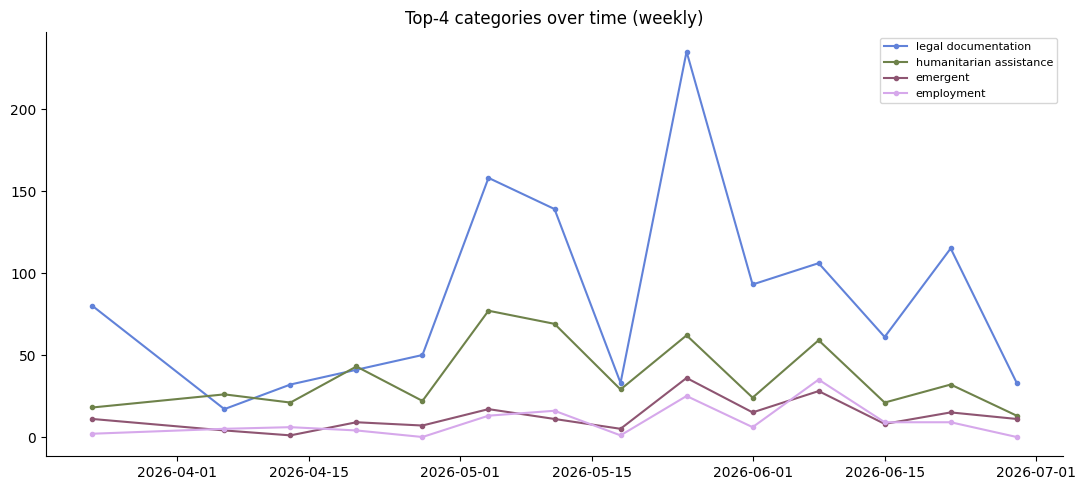

In [16]:
cats4 = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
         .value_counts().head(4).index)
trend = (msgs.dropna(subset=["ts"])
         .assign(week=lambda d: d["ts"].dt.to_period("W").dt.start_time)
         [lambda d: d["mmc_category"].isin(cats4)]
         .groupby(["week", "mmc_category"]).size().unstack(fill_value=0)
         .reindex(columns=cats4, fill_value=0))
fig, ax = plt.subplots(figsize=(11, 5))
for c in trend.columns:
    ax.plot(trend.index, trend[c], marker="o", ms=3, color=CAT_COLORS[c], label=c)
ax.set_title("Top-4 categories over time (weekly)"); ax.legend(fontsize=8)
plt.tight_layout()

## 7. Demographic profile vs. category

**What this shows.** How category demand differs by nationality, gender and age
band. **Why it matters.** It reveals which segments ask about what, so outreach
and content can be tailored.

> **Technical note.** Cells are row-normalised (share of that group's messages),
> so rows sum to 1 and small groups aren't swamped by large ones.

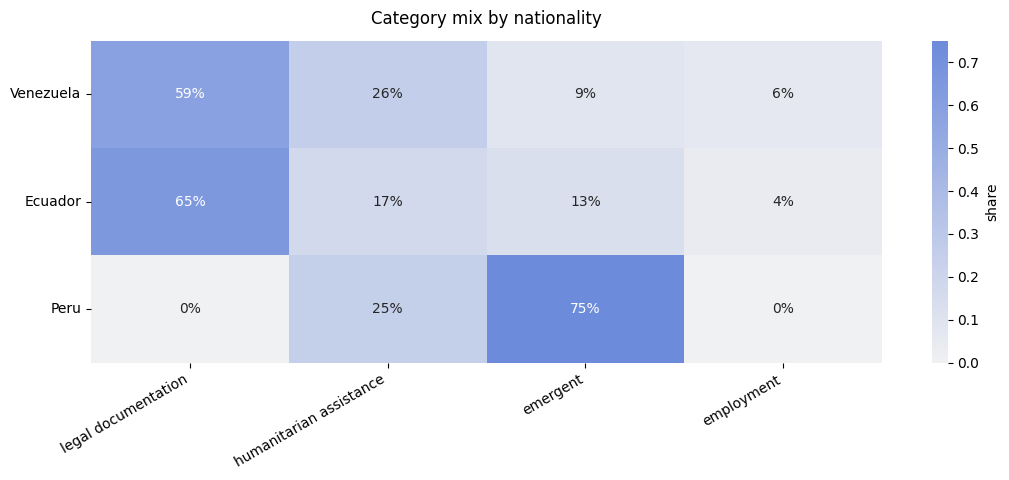

In [17]:
top_cats = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
            .value_counts().head(6).index)

def cat_heatmap(group_col, top_n=6, title=""):
    groups = msgs[group_col].value_counts().head(top_n).index
    sub = msgs[msgs[group_col].isin(groups) & msgs["mmc_category"].isin(top_cats)]
    mat = (pd.crosstab(sub[group_col], sub["mmc_category"], normalize="index")
           .reindex(index=groups, columns=top_cats, fill_value=0))
    # Height scales with the number of rows; width is fixed wide enough for the
    # long category names once they are angled.
    fig, ax = plt.subplots(figsize=(11, 0.7 * len(groups) + 2.8))
    sns.heatmap(mat, cmap=sns.light_palette(BLUES[5], as_cmap=True),
                annot=True, fmt=".0%", ax=ax, cbar_kws={"label": "share"})
    ax.set_title(title, pad=12)
    ax.set_xlabel(""); ax.set_ylabel("")
    # Angle the long category names so they stop overlapping; keep the group
    # labels (nationality / age range) horizontal and readable.
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()

cat_heatmap("Nationality", title="Category mix by nationality")

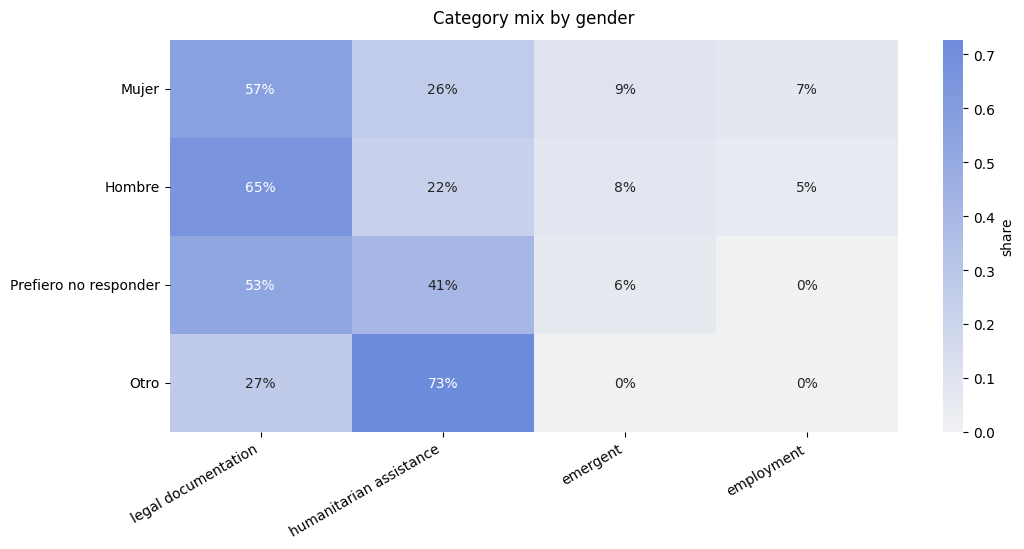

In [18]:
cat_heatmap("Gender", top_n=4, title="Category mix by gender")

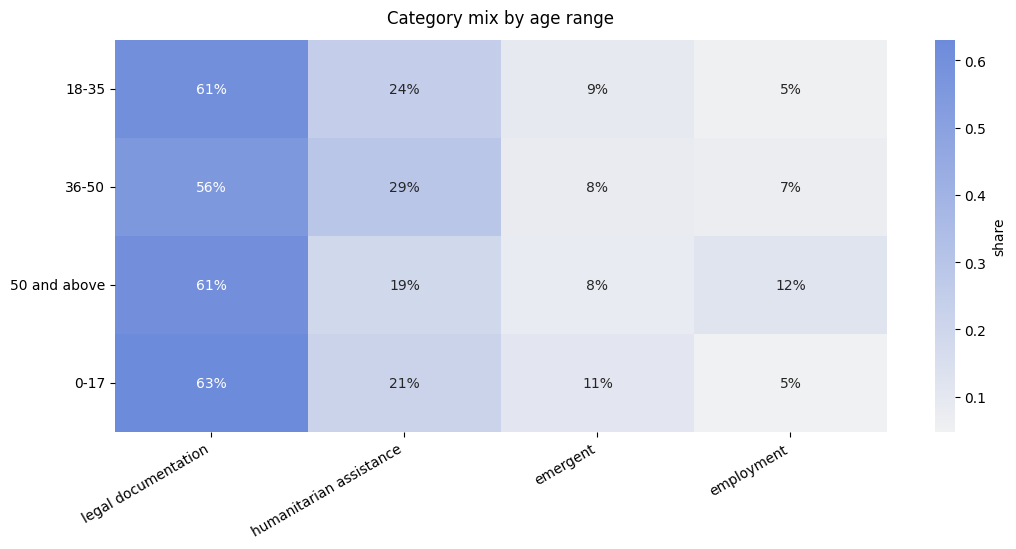

In [19]:
cat_heatmap("Age Ranges", top_n=4, title="Category mix by age range")

## 8. Engagement depth

**What this shows.** How many messages each user sends before stopping, and how
many write only once. **Why it matters.** Depth is a proxy for how much the bot
held people's attention.

> **Technical note.** Counted from the exploded spine (`n_msgs_user`), one value
> per user.

median 3  |  single-message share 24.8%  |  90th pct 7


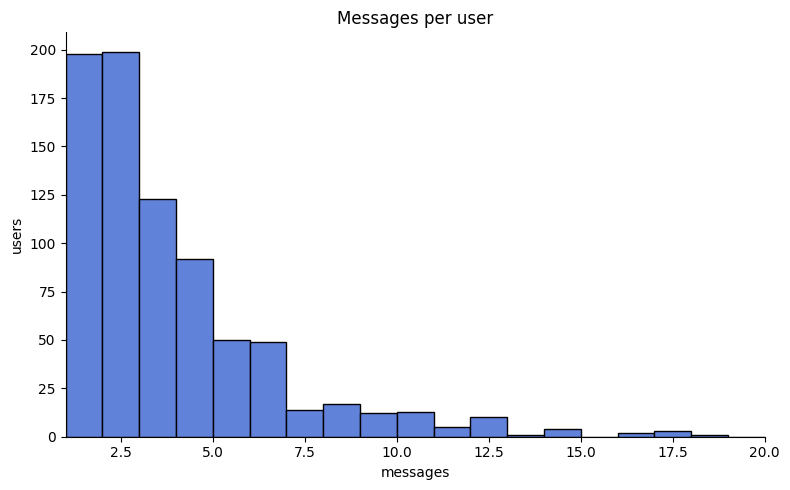

In [20]:
per_user = msgs.groupby("phone")["n_msgs_user"].first()
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(per_user, bins=range(1, int(per_user.max()) + 2), color=AGUA, edgecolor=NEGRO)
ax.set_title("Messages per user"); ax.set_xlabel("messages"); ax.set_ylabel("users")
ax.set_xlim(1, 20); plt.tight_layout()
print(f"median {per_user.median():.0f}  |  single-message share "
      f"{(per_user<=1).mean()*100:.1f}%  |  90th pct {per_user.quantile(.9):.0f}")

## 9. Drop-off & reformulated questions

**What this shows.** Where conversations end — the category and emotion of each
user's **last** message — and how often people **re-ask** the same thing.
**Why it matters.** The last message hints at what went unresolved; repeated
questions flag content gaps or unclear answers.

> **Technical note — user-side only.** We have no bot turns, so this is the
> user's own last message, not a true turn-level abandonment point. Reformulation
> = consecutive messages from the same user with embedding cosine ≥ 0.85 (an
> approximation of "asked again"). Emotion column comes from Section 10.

users ending on a courtesy message: 7.5%


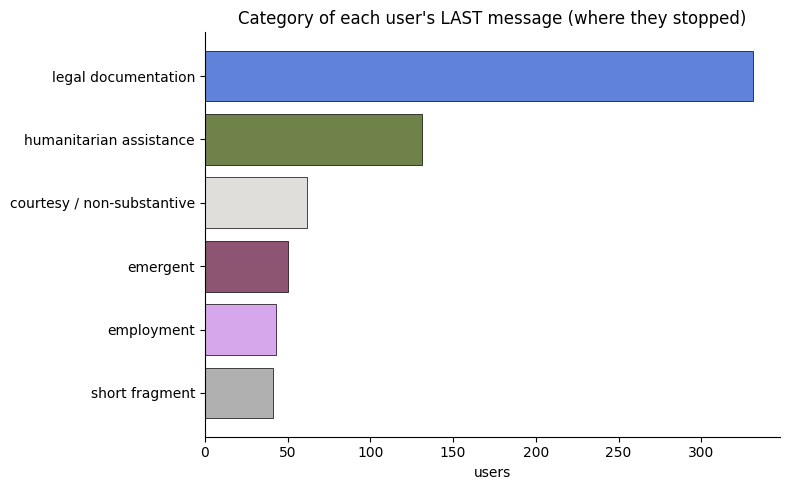

In [21]:
last = msgs[msgs["msg_idx"] == msgs["n_msgs_user"] - 1]
last_cat = last.loc[~last["mmc_category"].isin([NOISE]), "mmc_category"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 5))
o = last_cat.iloc[::-1]
ax.barh(o.index, o.values, color=cat_palette(o.index), edgecolor=NEGRO, lw=.5)
ax.set_title("Category of each user's LAST message (where they stopped)")
ax.set_xlabel("users"); plt.tight_layout()
print(f"users ending on a courtesy message: "
      f"{(last['mmc_category']==COURTESY).mean()*100:.1f}%")

multi-message users with >=1 reformulated pair: 60.9% (of 604 multi-message users)


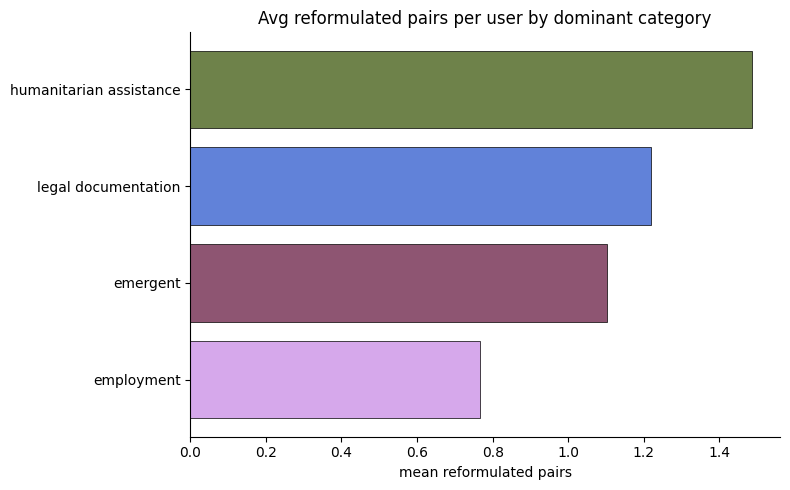

In [22]:
# reformulation: consecutive same-user messages with high embedding similarity
emb_norm = emb / np.clip(np.linalg.norm(emb, axis=1, keepdims=True), 1e-9, None)
REFORM_TH = 0.85
order = msgs.sort_values(["phone", "msg_idx"])
ref_rows = []
for phone, idx in order.groupby("phone").groups.items():
    idx = list(idx)
    if len(idx) < 2:
        continue
    sims = np.sum(emb_norm[idx[:-1]] * emb_norm[idx[1:]], axis=1)
    ref_rows.append((phone, int((sims >= REFORM_TH).sum())))
reform = pd.DataFrame(ref_rows, columns=["phone", "n_reform"])
share = (reform["n_reform"] > 0).mean() * 100
print(f"multi-message users with >=1 reformulated pair: {share:.1f}% "
      f"(of {len(reform)} multi-message users)")

# reformulation rate by the user's dominant category
dom = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]
       .groupby("phone")["mmc_category"].agg(lambda s: s.value_counts().index[0]))
rr = reform.merge(dom.rename("dom_cat"), on="phone")
by = rr.groupby("dom_cat")["n_reform"].mean().sort_values().tail(8)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by.index, by.values, color=cat_palette(by.index), edgecolor=NEGRO, lw=.5)
ax.set_title("Avg reformulated pairs per user by dominant category")
ax.set_xlabel("mean reformulated pairs"); plt.tight_layout()

## 10. Sentiment & emotion

**What this shows.** The tone of each message on two scales: a 3-way
**sentiment** (negative / neutral / positive) and a richer **7-way emotion**
(joy, sadness, anger, fear, surprise, disgust, others). **Why it matters.** Tone
is an unsolicited distress signal covering everyone who wrote — far more than the
few dozen MEAL respondents — and emotion adds nuance that plain polarity misses
for people in hard situations.

> **Technical note.** Sentiment: `cardiffnlp/twitter-xlm-roberta-base-sentiment`.
> Emotion: `pysentimiento/robertuito-emotion-analysis` (Spanish-native, 7
> classes). Both score each message on GPU. Reflects the **user's** wording only.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentiment: {'negative': np.int64(480), 'neutral': np.int64(2302), 'positive': np.int64(211)}
emotion: {'others': np.int64(2784), 'joy': np.int64(150), 'sadness': np.int64(38), 'anger': np.int64(11), 'surprise': np.int64(6), 'fear': np.int64(4)}
negative share: 16.0%


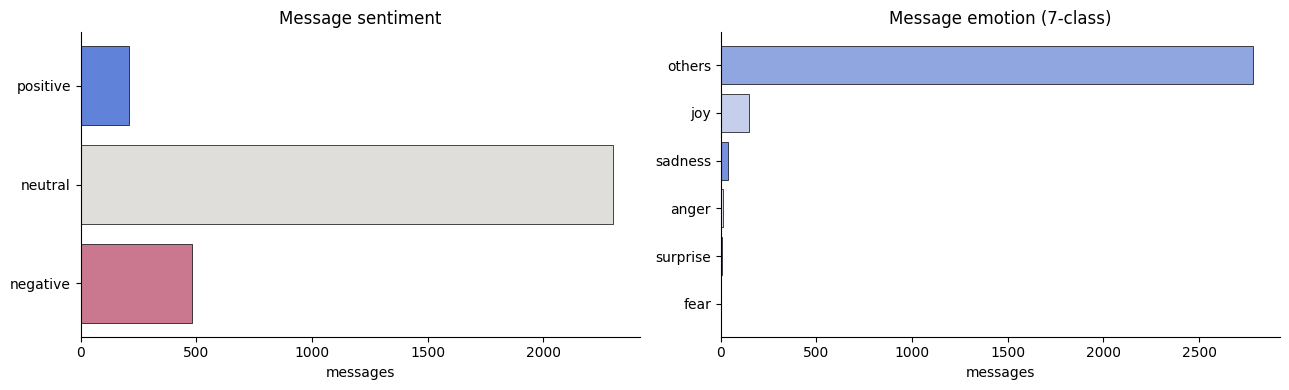

In [23]:
# --- 3-class sentiment ---
sent_clf = pipeline("sentiment-analysis",
                    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
                    device=GPU, truncation=True, max_length=256)
def _norm_sent(label):
    l = label.lower()
    if "neg" in l or l.endswith("0"): return "negative"
    if "pos" in l or l.endswith("2"): return "positive"
    return "neutral"
preds = sent_clf([t_[:256] for t_ in texts], batch_size=32)
msgs["sentiment"] = [_norm_sent(p["label"]) for p in preds]
del sent_clf
if DEVICE == "cuda": torch.cuda.empty_cache()

# --- 7-class emotion ---
emo = mmc_text.load_emotion_pipeline()
msgs["emotion"] = [r["label"] for r in emo(texts)]
del emo
if DEVICE == "cuda": torch.cuda.empty_cache()

SENT_ORDER = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": "#c9788f", "neutral": HONGO, "positive": AGUA}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sd = msgs["sentiment"].value_counts().reindex(SENT_ORDER)
axes[0].barh(SENT_ORDER, sd.values, color=[SENT_COLORS[s] for s in SENT_ORDER],
             edgecolor=NEGRO, lw=.5)
axes[0].set_title("Message sentiment"); axes[0].set_xlabel("messages")
ed = msgs["emotion"].value_counts()
axes[1].barh(ed.index[::-1], ed.values[::-1], color=bar_colors(len(ed)), edgecolor=NEGRO, lw=.5)
axes[1].set_title("Message emotion (7-class)"); axes[1].set_xlabel("messages")
plt.tight_layout()
print("sentiment:", dict(sd)); print("emotion:", dict(ed))
print(f"negative share: {sd['negative']/sd.sum()*100:.1f}%")

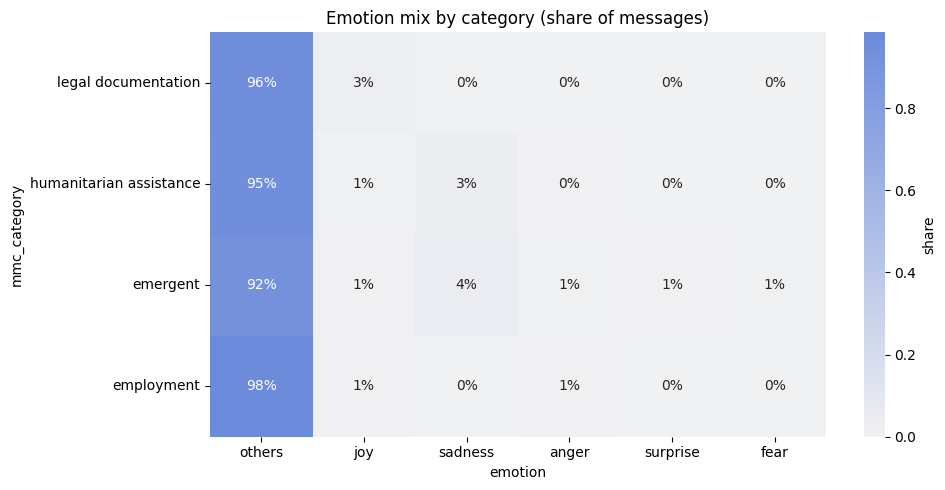

In [24]:
# emotion mix by category — which needs arrive with the most negative emotion
cats6 = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
         .value_counts().head(6).index)
sub = msgs[msgs["mmc_category"].isin(cats6)]
emo_order = msgs["emotion"].value_counts().index
tabE = (pd.crosstab(sub["mmc_category"], sub["emotion"], normalize="index")
        .reindex(index=cats6, columns=emo_order, fill_value=0))
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tabE, cmap=sns.light_palette(BLUES[5], as_cmap=True),
            annot=True, fmt=".0%", ax=ax, cbar_kws={"label": "share"})
ax.set_title("Emotion mix by category (share of messages)")
plt.tight_layout()

## 11. Satisfaction (MEAL) × category

**What this shows.** MEAL utility ratings joined to the category each user mostly
asked about. **Why it matters.** It flags which needs produce the worst
experience.

> **Technical note — small overlap.** Only users who completed the MEAL survey
> appear (dozens). Each user is assigned their dominant message category. Joined
> on WhatsApp phone number. Read proportions as directional.

users with both a category and a MEAL rating: 62


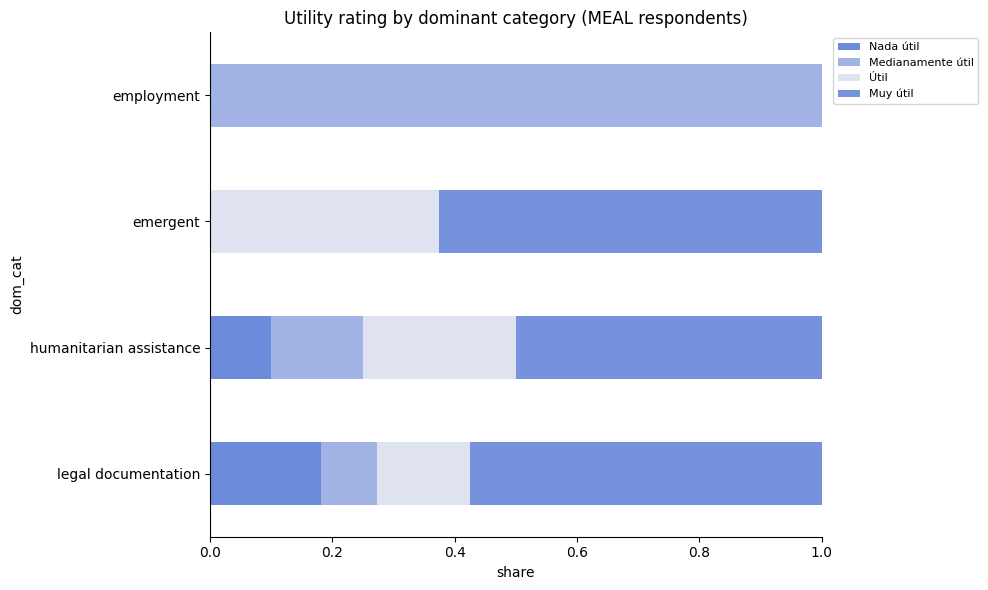

In [25]:
UTIL_ORDER = ["Nada útil", "Medianamente útil", "Útil", "Muy útil"]
dom_cat = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]
           .groupby("phone")["mmc_category"].agg(lambda s: s.value_counts().index[0])
           .rename("dom_cat").reset_index())
merged = dom_cat.merge(meal[["phone", "utility"]], on="phone", how="inner")
merged = merged[merged["utility"].isin(UTIL_ORDER)]
print(f"users with both a category and a MEAL rating: {len(merged)}")

cats6 = merged["dom_cat"].value_counts().head(6).index
sub = merged[merged["dom_cat"].isin(cats6)]
tabU = (pd.crosstab(sub["dom_cat"], sub["utility"], normalize="index")
        .reindex(index=cats6, columns=UTIL_ORDER, fill_value=0))
tabU.plot(kind="barh", stacked=True, figsize=(10, 6), color=bar_colors(4))
plt.title("Utility rating by dominant category (MEAL respondents)")
plt.xlabel("share"); plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 12. Geographic clustering — sentiment & category on the map

**What this shows.** Colombia with, per city, its **dominant need** (MMC category)
and the **average tone** of its messages. **Why it matters.** It turns the city
cross-tabs into a map — where a need concentrates and where people write in with
the most negative tone, to target field response.

> **Technical note.** One bubble per city (size = messages), positioned from a
> curated coordinate table. Only cities with ≥ 15 mapped messages are shown.
> Sentiment is the mean per-message polarity (−1 / 0 / +1); category is the most
> common per city. The Colombia outline is read from a one-time cached OSM
> geometry.

In [26]:
import os, unicodedata
import geopandas as gpd

CITY_COORDS = {
    "bogota": (-74.0721, 4.7110),   "medellin": (-75.5812, 6.2442),
    "cali": (-76.5320, 3.4516),     "barranquilla": (-74.7813, 10.9685),
    "cartagena": (-75.4794, 10.3910),"cucuta": (-72.5078, 7.8939),
    "bucaramanga": (-73.1227, 7.1193),"maicao": (-72.2382, 11.3776),
    "riohacha": (-72.9072, 11.5449),"ipiales": (-77.6417, 0.8256),
    "santa marta": (-74.1990, 11.2408),"soacha": (-74.2168, 4.5794),
    "necocli": (-76.7889, 8.4245),
}
def _strip(s):
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

msgs["city_key"] = msgs["city_canon"].map(_strip)
matched = msgs["city_key"].isin(CITY_COORDS)
print(f"{msgs.loc[matched,'city_key'].nunique()} cities mapped, "
      f"covering {matched.mean()*100:.0f}% of messages")

colombia = None
try:
    if os.path.exists("cache/colombia_boundary.gpkg"):
        colombia = gpd.read_file("cache/colombia_boundary.gpkg")
    else:
        import osmnx as ox
        colombia = ox.geocode_to_gdf("Colombia")[["geometry"]]
        os.makedirs("cache", exist_ok=True); colombia.to_file("cache/colombia_boundary.gpkg", driver="GPKG")
except Exception as e:
    print("Colombia outline unavailable:", repr(e)[:100])

MIN_MSGS = 15
SENT_SIGN = {"negative": -1, "neutral": 0, "positive": 1}
gm = msgs[matched & ~msgs["mmc_category"].isin(NON_TOPIC_CATS)].copy()
gm["sent_sign"] = gm["sentiment"].map(SENT_SIGN)
geo = gm.groupby("city_key").agg(msgs_n=("city_key", "size"), sentiment=("sent_sign", "mean"))
geo = geo[geo["msgs_n"] >= MIN_MSGS]
geo["dominant"] = gm.groupby("city_key")["mmc_category"].agg(lambda s: s.value_counts().index[0])
geo["lon"] = [CITY_COORDS[c][0] for c in geo.index]
geo["lat"] = [CITY_COORDS[c][1] for c in geo.index]
geo["label"] = [c.title() for c in geo.index]
geo = geo.sort_values("msgs_n", ascending=False)

def _basemap(ax, title):
    if colombia is not None:
        colombia.plot(ax=ax, color=MADERA_LIGHT, edgecolor=MADERA, lw=.6, zorder=0)
    ax.set_title(title); ax.set_axis_off(); ax.set_xlim(-80, -66); ax.set_ylim(-4.5, 13)
def _sizes(frame):
    return 60 + (frame["msgs_n"] / frame["msgs_n"].max()) * 900
print(f"{len(geo)} cities with >= {MIN_MSGS} messages mapped")
display(geo[["label", "msgs_n", "sentiment", "dominant"]].reset_index(drop=True))

13 cities mapped, covering 88% of messages
9 cities with >= 15 messages mapped


,label,msgs_n,sentiment,dominant
0,Medellin,747,-0.107095,legal documentation
1,Bogota,298,-0.124161,legal documentation
2,Barranquilla,217,-0.078341,legal documentation
3,Cucuta,118,-0.135593,legal documentation
4,Santa Marta,115,-0.121739,legal documentation
5,Soacha,95,-0.105263,legal documentation
6,Ipiales,88,-0.045455,humanitarian assistance
7,Maicao,31,-0.225806,humanitarian assistance
8,Cali,19,-0.157895,humanitarian assistance


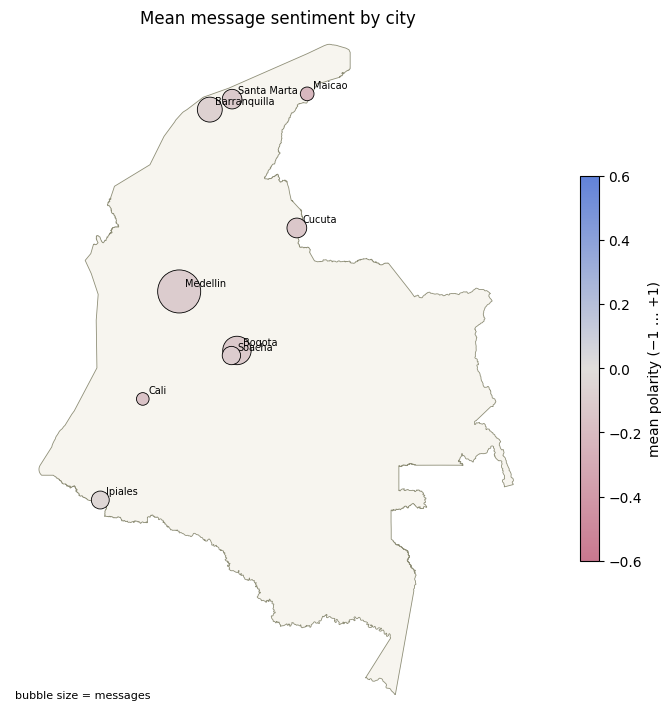

In [27]:
from matplotlib.colors import LinearSegmentedColormap
sent_cmap = LinearSegmentedColormap.from_list("mmc_sent", ["#c9788f", HONGO, AGUA])
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Mean message sentiment by city")
sc = ax.scatter(geo["lon"], geo["lat"], s=_sizes(geo), c=geo["sentiment"],
                cmap=sent_cmap, vmin=-0.6, vmax=0.6, edgecolor=NEGRO, lw=.6, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
cbar = plt.colorbar(sc, ax=ax, shrink=0.5); cbar.set_label("mean polarity (−1 … +1)")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

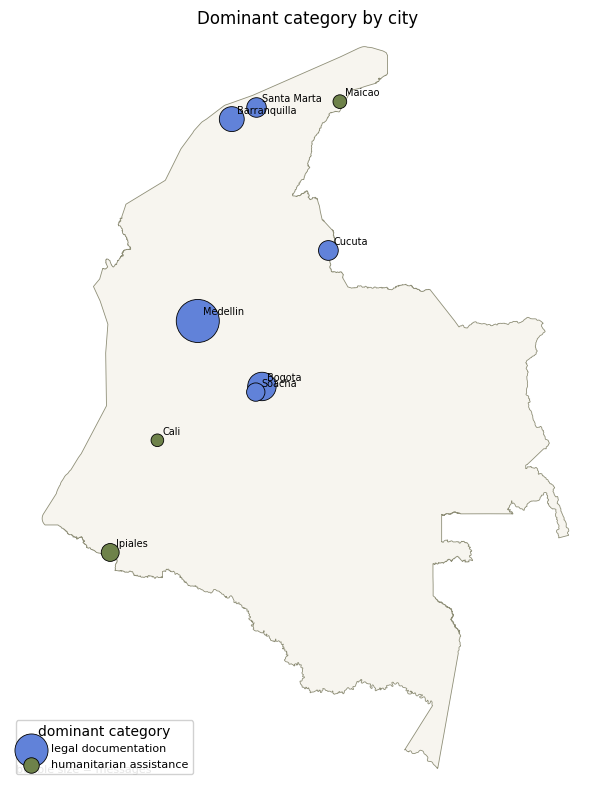

In [28]:
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Dominant category by city")
sizes = _sizes(geo)
for cat in geo["dominant"].unique():
    m = geo["dominant"] == cat
    ax.scatter(geo.loc[m, "lon"], geo.loc[m, "lat"], s=sizes[m],
               color=CAT_COLORS.get(cat, NEGRO), edgecolor=NEGRO, lw=.6, label=cat, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
ax.legend(loc="lower left", fontsize=8, framealpha=.9, title="dominant category")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()